Bike data / Feature Engineering

In [47]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [3]:
df= pd.read_csv("../data/bike.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [5]:
df.isna().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [6]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


Visualization

In [7]:
fig = px.histogram(df[["count", "casual", "registered"]])
fig.show()

In [8]:
fig = px.histogram(df[["temp", "atemp"]])
fig.show()  

In [9]:
fig = px.histogram(df[["weather"]])
fig.show()

In [10]:
fig = px.histogram(df[["humidity"]])
fig.show()

In [11]:
fig = px.histogram(df[["windspeed"]])
fig.show()

In [12]:
corr = df.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm').set_caption("Correlation Matrix")

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


Outlier removal

In [13]:
#boxplot
fig = px.box(df[["windspeed"]])
fig.show()

In [14]:
q1= np.quantile(df["windspeed"], 0.25)
q3= np.quantile(df["windspeed"], 0.75)
iqr = q3 - q1
lower_bound = q1 -1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df = df[(df["windspeed"] >= lower_bound) & (df["windspeed"] <= upper_bound)]
df.shape

(10659, 12)

In [15]:
fig = px.histogram(df[["windspeed"]])
fig.show()

In [16]:
df.shape

(10659, 12)

Transformation

In [17]:
count_transformed = np.log1p(df["count"])

fig = px.histogram(count_transformed)
fig.show()

In [18]:
casual_transformed = np.log1p(df["casual"])

fig = px.histogram(casual_transformed)
fig.show()

In [19]:
registered_transformed = np.log1p(df["registered"])

fig = px.histogram(registered_transformed)
fig.show()

Cyclic Features

In [21]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


<Axes: >

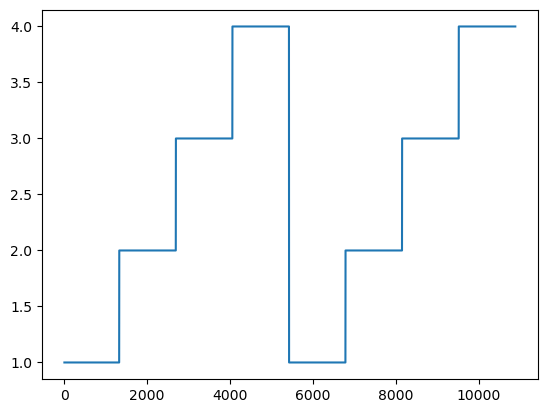

In [20]:
df['season'].plot()

In [22]:
df['season_sin'] = np.sin(2 * np.pi * df['season']/4)
df['season_cos'] = np.cos(2 * np.pi * df['season']/4)

In [23]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,season_sin,season_cos
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1.0,6.123234e-17
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1.0,6.123234e-17
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1.0,6.123234e-17
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1.0,6.123234e-17
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1.0,6.123234e-17


<Axes: >

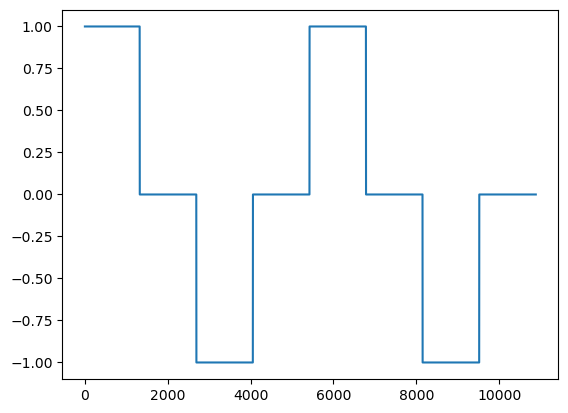

In [24]:
df['season_sin'].plot()

<Axes: xlabel='season_sin', ylabel='season_cos'>

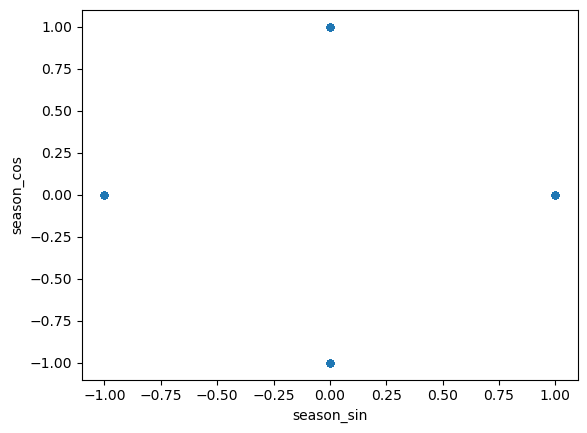

In [27]:
df.plot.scatter('season_sin', 'season_cos')

Date/time

In [29]:
df.dtypes

datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
season_sin    float64
season_cos    float64
dtype: object

In [30]:
df['new_datetime']= pd.to_datetime(df['datetime'], format='%Y-%m-%d %H:%M:%S')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,season_sin,season_cos,new_datetime
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1.0,6.123234e-17,2011-01-01 00:00:00
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1.0,6.123234e-17,2011-01-01 01:00:00
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1.0,6.123234e-17,2011-01-01 02:00:00
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1.0,6.123234e-17,2011-01-01 03:00:00
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1.0,6.123234e-17,2011-01-01 04:00:00


In [31]:
df.dtypes

datetime                   str
season                   int64
holiday                  int64
workingday               int64
weather                  int64
temp                   float64
atemp                  float64
humidity                 int64
windspeed              float64
casual                   int64
registered               int64
count                    int64
season_sin             float64
season_cos             float64
new_datetime    datetime64[us]
dtype: object

In [32]:
df['year'] = df['new_datetime'].dt.year
df['month'] = df['new_datetime'].dt.month
df['day'] = df['new_datetime'].dt.day
df['day_of_week'] = df['new_datetime'].dt.dayofweek
df['hour'] = df['new_datetime'].dt.hour

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,season_sin,season_cos,new_datetime,year,month,day,day_of_week,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1.0,6.123234e-17,2011-01-01 00:00:00,2011,1,1,5,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1.0,6.123234e-17,2011-01-01 01:00:00,2011,1,1,5,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1.0,6.123234e-17,2011-01-01 02:00:00,2011,1,1,5,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1.0,6.123234e-17,2011-01-01 03:00:00,2011,1,1,5,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1.0,6.123234e-17,2011-01-01 04:00:00,2011,1,1,5,4


In [33]:
print("Months:", df["month"].unique().tolist())
print("Days:", df["day"].unique().tolist())
print("Day of week:", df["day_of_week"].unique().tolist())
print("Hours:", df["hour"].unique().tolist())
print("Years:", df["year"].unique().tolist())

Months: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Days: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Day of week: [5, 6, 0, 1, 2, 3, 4]
Hours: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Years: [2011, 2012]


In [34]:
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

df['day_sin'] = np.sin(2 * np.pi * df['day']/19)
df['day_cos'] = np.cos(2 * np.pi * df['day']/19)

df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,...,day_of_week,hour,month_sin,month_cos,day_sin,day_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,...,5,0,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.000000,1.000000
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,...,5,1,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.258819,0.965926
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,...,5,2,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.500000,0.866025
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,...,5,3,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.707107,0.707107
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,...,5,4,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.866025,0.500000


<Axes: xlabel='day_sin', ylabel='day_cos'>

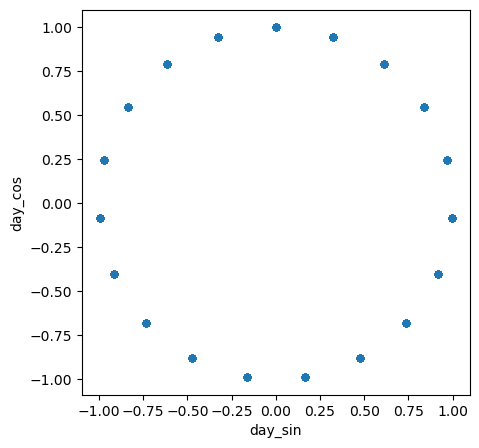

In [39]:
df.plot.scatter('day_sin', 'day_cos', figsize=(5,5))

<Axes: xlabel='month_sin', ylabel='month_cos'>

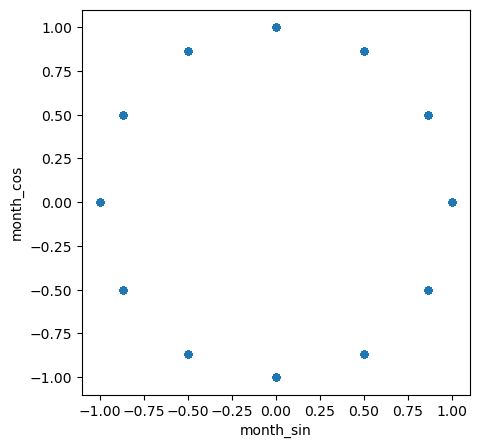

In [40]:
df.plot.scatter('month_sin', 'month_cos', figsize=(5,5))

In [ ]:
#Drop the original columns that have been transformed
df.drop(columns=['season', 'month', 'day', 'day_of_week', 'hour', 'datetime', 'year'], inplace=True)
df.drop(columns=['new_datetime'], inplace=True)
df.head()

,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,...,season_cos,new_datetime,month_sin,month_cos,day_sin,day_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,0,0,1,9.84,14.395,81,0.0,3,13,16,...,6.123234e-17,2011-01-01 00:00:00,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.000000,1.000000
1,0,0,1,9.02,13.635,80,0.0,8,32,40,...,6.123234e-17,2011-01-01 01:00:00,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.258819,0.965926
2,0,0,1,9.02,13.635,80,0.0,5,27,32,...,6.123234e-17,2011-01-01 02:00:00,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.500000,0.866025
3,0,0,1,9.84,14.395,75,0.0,3,10,13,...,6.123234e-17,2011-01-01 03:00:00,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.707107,0.707107
4,0,0,1,9.84,14.395,75,0.0,0,1,1,...,6.123234e-17,2011-01-01 04:00:00,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.866025,0.500000


In [43]:
df.drop(columns=['new_datetime'], inplace=True)
df.head()

,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,season_sin,season_cos,month_sin,month_cos,day_sin,day_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
0,0,0,1,9.84,14.395,81,0.0,3,13,16,1.0,6.123234e-17,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.000000,1.000000
1,0,0,1,9.02,13.635,80,0.0,8,32,40,1.0,6.123234e-17,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.258819,0.965926
2,0,0,1,9.02,13.635,80,0.0,5,27,32,1.0,6.123234e-17,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.500000,0.866025
3,0,0,1,9.84,14.395,75,0.0,3,10,13,1.0,6.123234e-17,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.707107,0.707107
4,0,0,1,9.84,14.395,75,0.0,0,1,1,1.0,6.123234e-17,0.5,0.866025,0.324699,0.945817,-0.974928,-0.222521,0.866025,0.500000


In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 10659 entries, 0 to 10885
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   holiday          10659 non-null  int64  
 1   workingday       10659 non-null  int64  
 2   weather          10659 non-null  int64  
 3   temp             10659 non-null  float64
 4   atemp            10659 non-null  float64
 5   humidity         10659 non-null  int64  
 6   windspeed        10659 non-null  float64
 7   casual           10659 non-null  int64  
 8   registered       10659 non-null  int64  
 9   count            10659 non-null  int64  
 10  season_sin       10659 non-null  float64
 11  season_cos       10659 non-null  float64
 12  month_sin        10659 non-null  float64
 13  month_cos        10659 non-null  float64
 14  day_sin          10659 non-null  float64
 15  day_cos          10659 non-null  float64
 16  day_of_week_sin  10659 non-null  float64
 17  day_of_week_cos  10659 non-n

In [45]:
df.describe()

,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,season_sin,season_cos,month_sin,month_cos,day_sin,day_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
count,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,10659.000000,1.065900e+04,1.065900e+04,1.065900e+04,1.065900e+04,1.065900e+04,10659.000000,10659.000000,10659.000000,1.065900e+04,1.065900e+04
mean,0.028614,0.680645,1.417112,20.268901,23.713577,62.214373,12.292752,36.020358,155.537480,191.557838,-1.332208e-02,3.471245e-03,-1.276633e-02,-4.928541e-03,-4.826155e-04,-0.000412,-0.005862,-0.000008,2.077814e-03,2.654967e-03
std,0.166728,0.466248,0.631143,7.788440,8.443245,19.083557,7.441015,49.961301,151.105693,181.211409,7.033222e-01,7.108039e-01,7.049481e-01,7.091930e-01,7.078112e-01,0.706468,0.708129,0.706125,7.066670e-01,7.076045e-01
min,0.000000,0.000000,1.000000,0.820000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-9.965845e-01,-0.986361,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00
25%,0.000000,0.000000,1.000000,13.940000,16.665000,47.000000,7.001500,4.000000,35.500000,42.000000,-1.000000e+00,-1.000000e+00,-8.660254e-01,-8.660254e-01,-7.357239e-01,-0.677282,-0.781831,-0.900969,-7.071068e-01,-7.071068e-01
50%,0.000000,1.000000,1.000000,20.500000,24.240000,62.000000,11.001400,17.000000,118.000000,145.000000,-2.449294e-16,-1.836970e-16,-2.449294e-16,-1.836970e-16,-2.449294e-16,-0.082579,0.000000,-0.222521,1.224647e-16,6.123234e-17
75%,0.000000,1.000000,2.000000,26.240000,31.060000,78.000000,16.997900,49.000000,223.000000,285.000000,1.224647e-16,1.000000e+00,5.000000e-01,5.000000e-01,7.357239e-01,0.789141,0.781831,0.623490,7.071068e-01,7.071068e-01
max,1.000000,1.000000,4.000000,41.000000,45.455000,100.000000,31.000900,367.000000,886.000000,977.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,9.965845e-01,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00


In [46]:
df['windspeed'].describe()

count    10659.000000
mean        12.292752
std          7.441015
min          0.000000
25%          7.001500
50%         11.001400
75%         16.997900
max         31.000900
Name: windspeed, dtype: float64

Data Scaling

StandardScaler

In [48]:
columns_to_scale = ['weather', 'temp', 'atemp', 'humidity', 'windspeed']

scaler = StandardScaler()
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [49]:
df[columns_to_scale].describe()

,weather,temp,atemp,humidity,windspeed
count,1.065900e+04,1.065900e+04,1.065900e+04,1.065900e+04,1.065900e+04
mean,2.093165e-16,2.879768e-16,-1.386555e-16,-5.332904e-18,-5.332904e-18
std,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00
min,-6.609154e-01,-2.497267e+00,-2.718701e+00,-3.260257e+00,-1.652104e+00
25%,-6.609154e-01,-8.126400e-01,-8.348577e-01,-7.972878e-01,-7.111261e-01
50%,-6.609154e-01,2.967339e-02,6.235132e-02,-1.123391e-02,-1.735533e-01
75%,9.235869e-01,7.666976e-01,8.701356e-01,8.272236e-01,6.323558e-01
max,4.092591e+00,2.661903e+00,2.575129e+00,1.980103e+00,2.514311e+00
